In [87]:
%load_ext autoreload
%autoreload 2

from dataclasses import dataclass
from py_files.capinc import CapIncModel

import py_files.simulation_1 as simulation_1
import py_files.simulation_2 as simulation_2 
import py_files.var_groups as var_groups
import numpy as np
import matplotlib.pyplot as plt
import importlib
import math
import py_files.fig_setup as fs
import matplotlib.ticker as mticker

importlib.reload(fs)     
fs.set_aej()    

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# `Interest rate` data fetch

Possible source for addition: https://www.oecd.org/en/data/datasets/corporate-income-tax-rates-database.html
- Corporate income tax (CIT) - statutory and targeted small business rates
- 2000: 32% and 2025: 22%

https://data-explorer.oecd.org/vis?fs[0]=Topic%2C1%7CTaxation%23TAX%23%7CCorporate%20tax%23TAX_CPT%23&pg=0&fc=Topic&bp=true&snb=19&df[ds]=dsDisseminateFinalDMZ&df[id]=DSD_TAX_CIT%40DF_CIT&df[ag]=OECD.CTP.TPS&df[vs]=2.0&dq=DNK.A.CIT.ST..S13%2BS1311%2BS13M...&pd=2000%2C2025&to[TIME_PERIOD]=false&vw=tl

Using API, I get CIT data for DK from 2020-2025:

In [88]:
url = (
    "https://sdmx.oecd.org/public/rest/data/"
    "OECD.CTP.TPS,DSD_TAX_CIT@DF_CIT,1.0/"
    "DNK.A..ST..S13+S1311+S13M.."
    "?startPeriod=2000&endPeriod=2025"
    "&dimensionAtObservation=AllDimensions"
    "&format=csvfilewithlabels"
)

r = requests.get(url)

r.raise_for_status()
df = pd.read_csv(StringIO(r.text))

# keep only the statutory CIT rate
df_cit = (df.loc[df["MEASURE"] == "CIT", ["TIME_PERIOD", "OBS_VALUE"]]
            .rename(columns={"TIME_PERIOD": "year", "OBS_VALUE": "cit_rate"})
            .assign(year=lambda x: x["year"].astype(int))
            .sort_values("year")
            .reset_index(drop=True))

*compare with alternative path $\{\tau\}_t^T$*

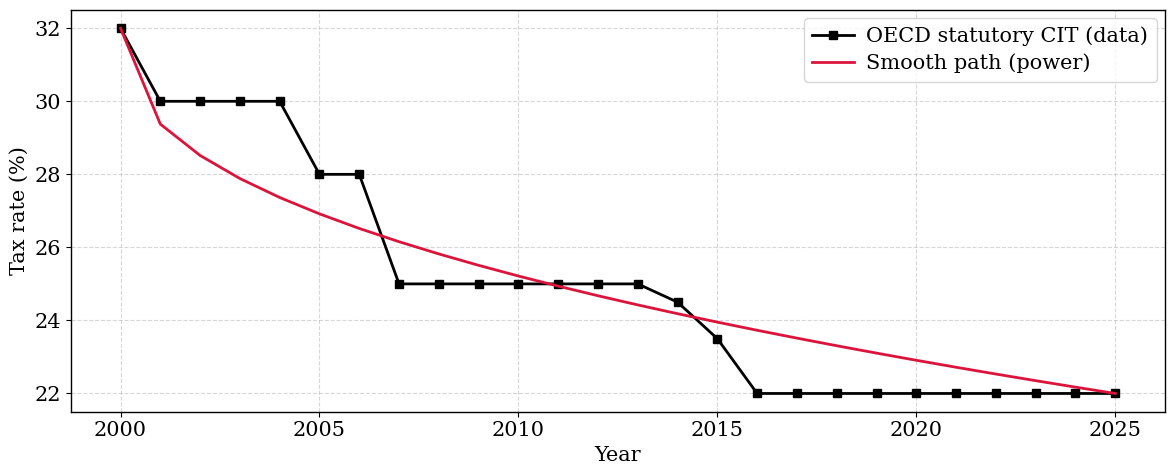

In [89]:
y0 = int(df_cit["year"].min())
yT = int(df_cit["year"].max())
T  = yT - y0

tau0 = df_cit.loc[df_cit["year"] == y0, "cit_rate"].iloc[0] / 100
tauT = df_cit.loc[df_cit["year"] == yT, "cit_rate"].iloc[0] / 100

_, tau_t, _ = simulation_2.net_tax_path_power(T=T, tau0=tau0, tauT=tauT, kappa=0.4)
years_model = np.arange(y0, yT + 1)

# --- plot ---
plt.figure(figsize=(12, 5))
plt.plot(df_cit["year"], df_cit["cit_rate"], linewidth=2, marker="s", label="OECD statutory CIT (data)", color='k')
plt.plot(years_model, 100 * tau_t, linewidth=2, label=r"Smooth path (power)", color='crimson')
plt.xlabel("Year")
plt.ylabel("Tax rate (%)")
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

> not the right function, should approach the final value with less slope at the end.

*make alternative simulation, using empirical path*

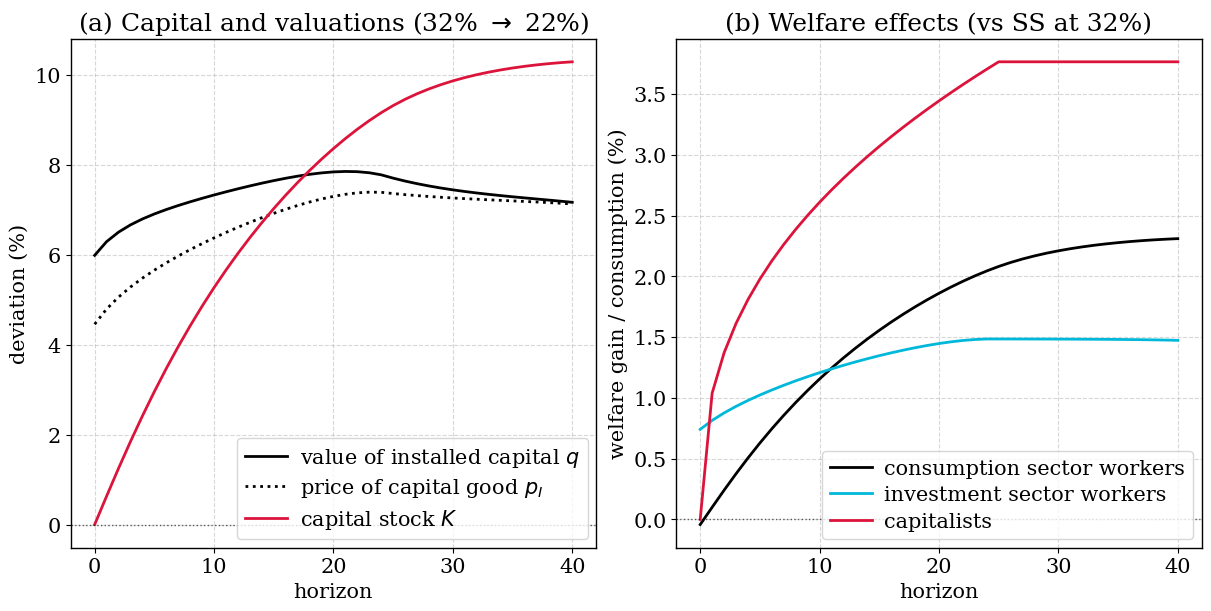

In [90]:
# run
m = CapIncModel()

fig, axes, ss, sim, paths = simulation_2.plot_figure5_reform(
    m, 
    T=40, 
    tau_ss=0.32, 
    tauT=0.22, 
    kappa=0.4
)

plt.show()

*and assess the labour share*

In [91]:
gamma = 0.80
T     = 40
tau0  = 0.32
tauT  = 0.22

m = CapIncModel()

# anchor baseline SS at tau0
ss0 = m.solve_steady_state(tau=tau0)

# paths
_, tau_t1, _ = simulation_2.net_tax_path_power(T=T, tau0=tau0, tauT=tauT, kappa=0.4)
tau_t2 = np.full_like(tau_t1, tau0)

# reform: close at tauT, but START from tau0 SS
sim1 = m.solve_transition(tau_path=tau_t1, K0=ss0["K"],
                          q_guess_path=np.full(T+1, ss0["q"]),
                          tau_terminal=tauT)
ls1  = simulation_2.labour_share(m, sim1, gamma=gamma)

# baseline: close at tau0 and START from tau0 SS
sim2 = m.solve_transition(tau_path=tau_t2, K0=ss0["K"],
                          q_guess_path=np.full(T+1, ss0["q"]),
                          tau_terminal=tau0)
ls2  = simulation_2.labour_share(m, sim2, gamma=gamma)

h = np.arange(len(ls1["LS"])) 

c:\Users\LinusLindquist\anaconda3\Lib\site-packages\scipy\optimize\_nonlin.py:374: RuntimeWarning: invalid value encountered in scalar divide
  and dx_norm/self.x_rtol <= x_norm))


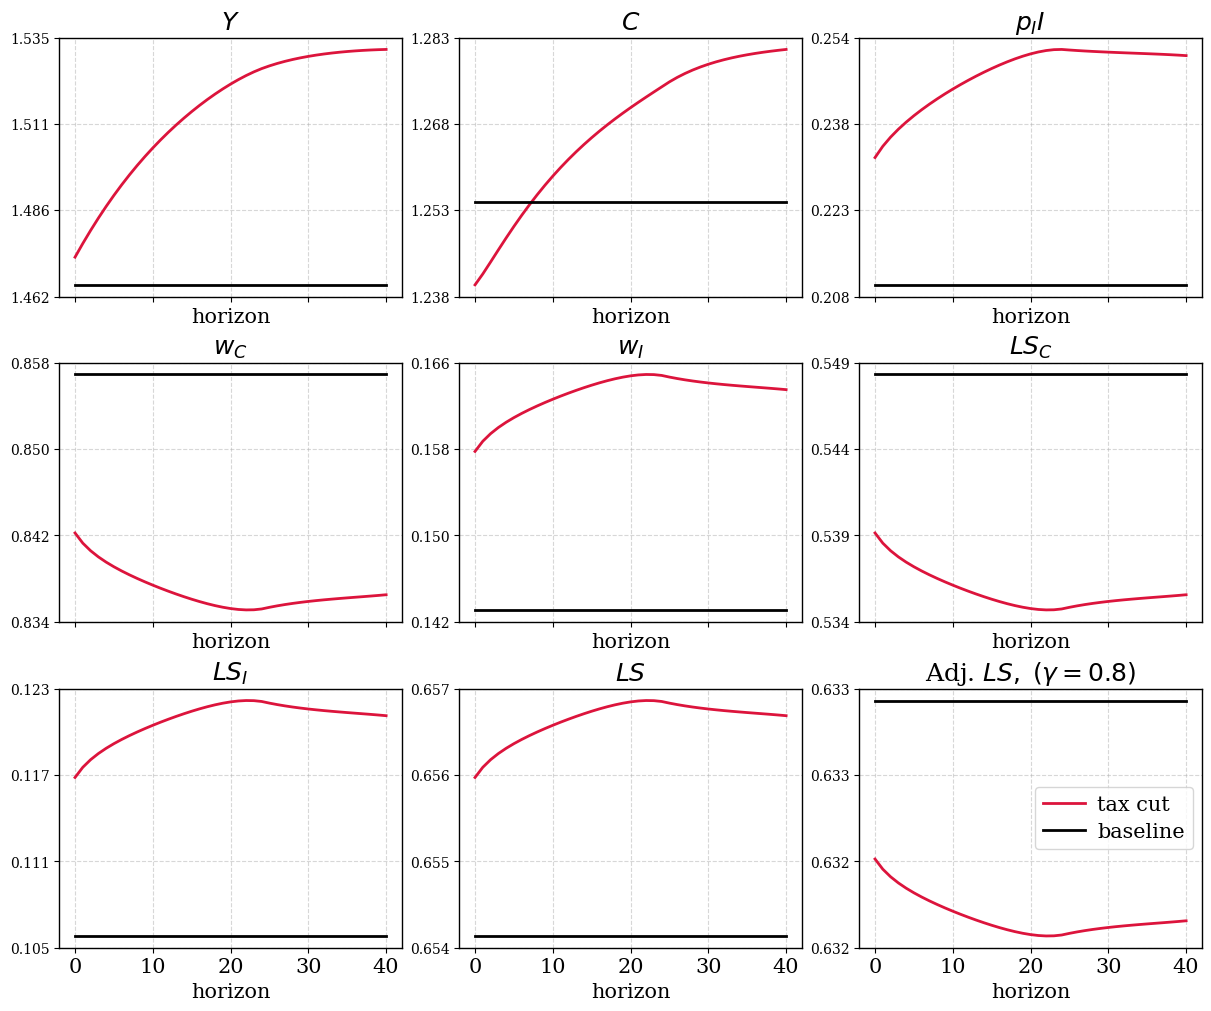

In [92]:
fig, axes = plt.subplots(3, 3, figsize=(12, 10), sharex=True, constrained_layout=True)
axes = axes.ravel()

# plot the 7 used panels
for i, (k, ttl) in enumerate(var_groups.panels(gamma)):
    ax = axes[i]
    l1, = ax.plot(h, ls1[k], lw=2, color="crimson", label="tax cut")
    l2, = ax.plot(h, ls2[k], lw=2, color="k",       label="baseline")
    ax.set_title(ttl)
    ax.set_xlabel("horizon")
    ax.grid(True, which="both", linestyle="--", alpha=0.5)

    ax.yaxis.set_major_locator(mticker.LinearLocator(4))
    ax.yaxis.set_minor_locator(mticker.NullLocator())
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))
    ax.tick_params(axis="y", labelsize=10)

plt.legend()
plt.show()

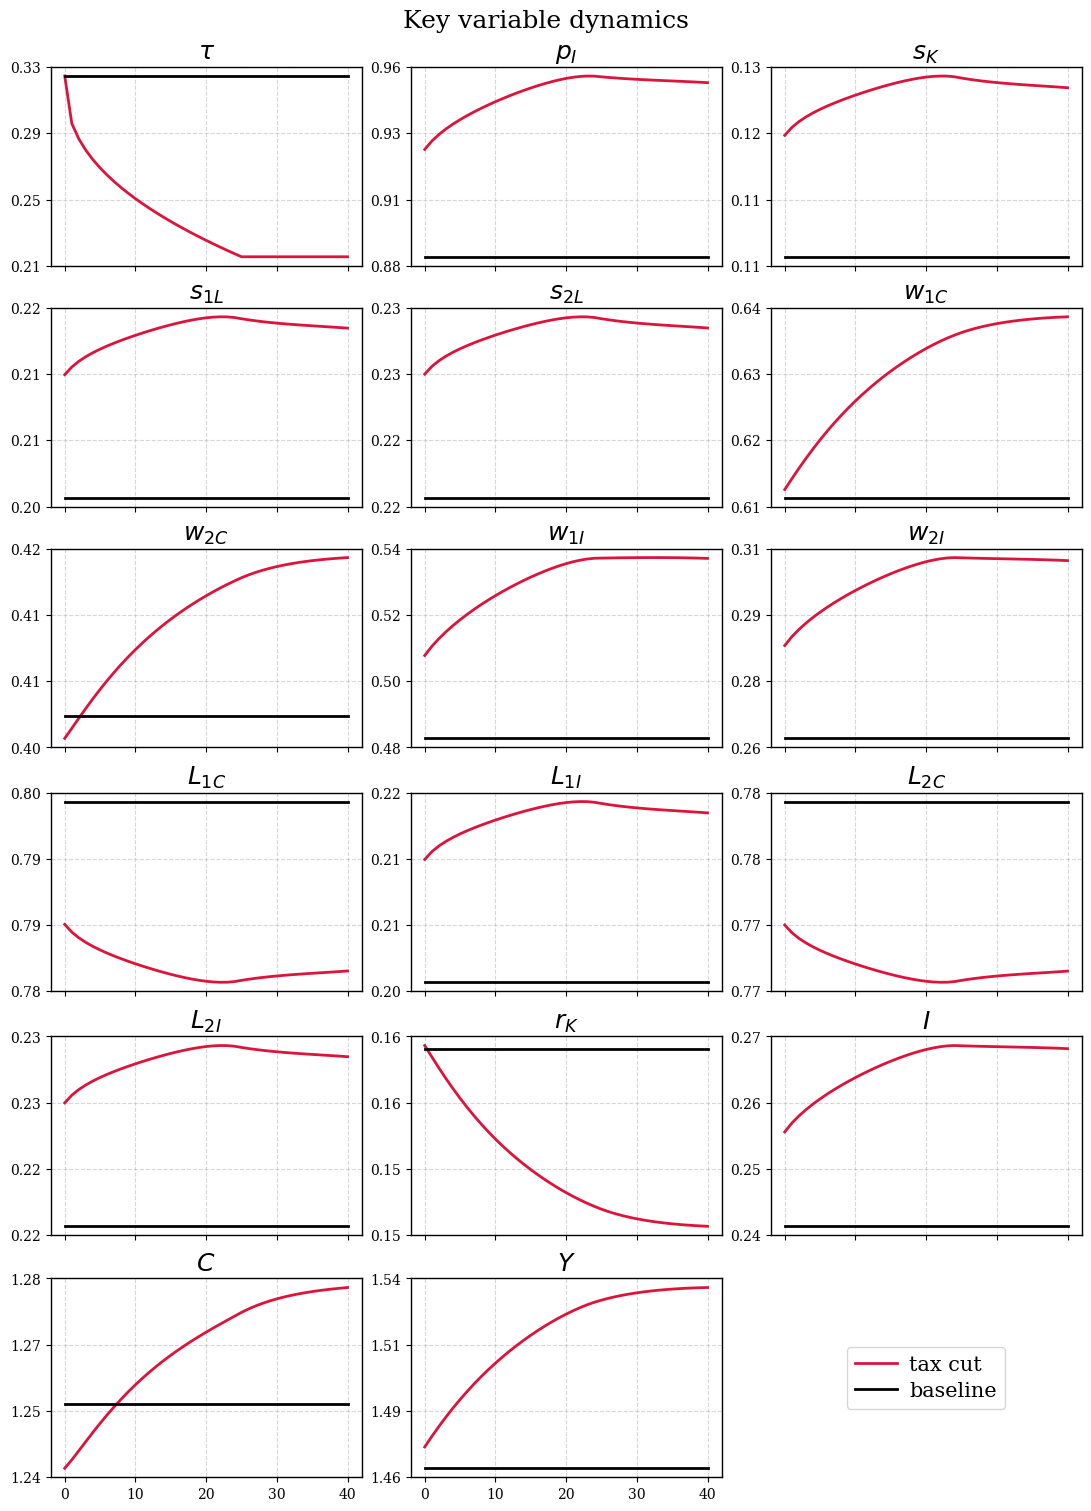

In [93]:
# pack everything
S1 = {**sim1, **ls1}
S2 = {**sim2, **ls2}

# choose/order keys (edit freely)
keys = [
    "tau",'pI',
    "sK","s1","s2",
    "w1C","w2C","w1I","w2I",
    "L1C","L1I","L2C","L2I",
    "rC_gross","I","C","Y"
]

T = min(len(S1[keys[0]]), len(S2[keys[0]]))
h = np.arange(T)

ncols = 3
nrows = math.ceil(len(keys) / ncols)

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(3.6*ncols, 2.5*nrows),
    sharex=True,
    constrained_layout=True
)
axes = np.atleast_1d(axes).ravel()
fig.suptitle('Key variable dynamics')

for i, k in enumerate(keys):
    ax = axes[i]
    ax.plot(h, np.asarray(S1[k])[:T], lw=2, color="crimson")
    ax.plot(h, np.asarray(S2[k])[:T], lw=2, color="k")
    ax.set_title(var_groups.model_var.get(k, k))
    ax.grid(True, which="both", linestyle="--", alpha=0.5)

for ax in axes:
    ax.yaxis.set_major_locator(mticker.LinearLocator(4))
    ax.yaxis.set_minor_locator(mticker.NullLocator())
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    ax.tick_params(axis="y", labelsize=10)
    ax.tick_params(axis="x", labelsize=10)
    
    
# hide any unused panels
for j in range(len(keys), len(axes)):
    axes[j].set_axis_off()

# one legend for the whole figure
axes[0].plot([], [], lw=2, color="crimson", label="tax cut")
axes[0].plot([], [], lw=2, color="k",  label="baseline")

first_empty = len(keys)

# 2) turn all unused axes off
for j in range(first_empty, len(axes)):
    axes[j].set_axis_off()

# 3) use the first empty one to host the legend
if first_empty < len(axes):
    ax_leg = axes[first_empty]
    ax_leg.set_axis_off()

    # proxy handles (clean + independent of what's plotted)
    h1 = plt.Line2D([0], [0], color="crimson", lw=2)
    h2 = plt.Line2D([0], [0], color="k",  lw=2)

    ax_leg.legend([h1, h2], ["tax cut", "baseline"], loc="center", frameon=True)

plt.show()